# Feature Engineering and Regression Pipeline
### 1. Date Feature Engineering

In [1]:
!pip install matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# 1. Load Data
df = pd.read_csv('../data/q3_retail_promotions.csv')

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Feature Engineering
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print(df.head())

  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

### 2. Temporal Train-Test Split

In [3]:
df = df.sort_values('transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

**Why a random split is inappropriate for time-ordered data:**

In time-ordered datasets, observations are sequential and depend on past events. Using a random train-test split breaks this natural order and can lead to **data leakage**, where information from the future is unintentionally used to predict the past.

For example:

* If we randomly split the data, the training set may contain records from **later dates**, while the test set may contain **earlier dates**.
* This allows the model to learn patterns from the future, which would not be available in a real-world scenario.

This results in:

* Overly optimistic performance metrics
* Poor generalization when deployed in real-time

Instead, a **temporal split** is used:

* Train on older data (past)
* Test on newer data (future)

This approach better simulates real-world conditions where predictions are always made on unseen future data, ensuring a more reliable evaluation of model performance.


### 3. Preprocessing Pipeline

In [4]:
categorical = ['promotion_type', 'location_type', 'store_size']
numerical = [col for col in X_train.columns if col not in categorical]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

### 4. Model Training and Evaluation


Linear Regression
RMSE: 27.12145116489063
MAE: 21.052926674588395


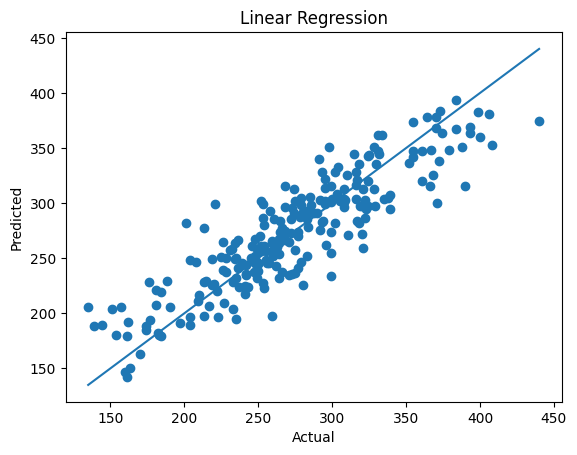


Random Forest
RMSE: 30.841610008504205
MAE: 24.240625


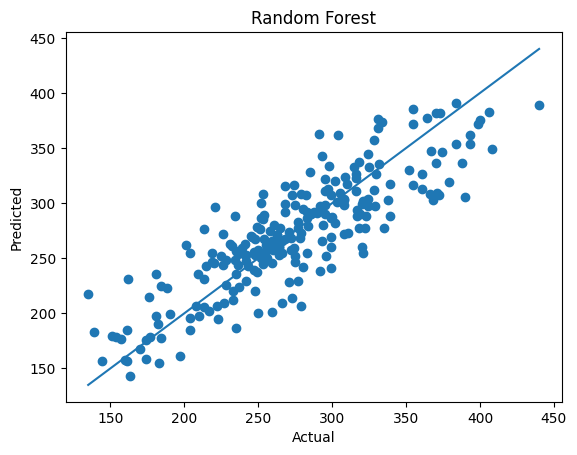

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

    # Parity plot
    plt.scatter(y_test, preds)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(name)
    plt.show()

In [6]:
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

model = rf_pipeline.named_steps['model']

# Get feature names
ohe = rf_pipeline.named_steps['prep'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical)

all_features = list(cat_features) + numerical

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(5))

                feature  importance
13          is_festival    0.173473
10     store_size_small    0.167683
7   location_type_urban    0.108378
17          day_of_week    0.086316
12           is_weekend    0.061208
